In [2]:
import sys
print(sys.executable)

c:\Users\rocky\Downloads\retail-demand-forecasting\venv\Scripts\python.exe


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

plt.style.use("ggplot")

In [2]:
train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")

In [3]:
train.shape

(913000, 4)

In [4]:
train.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   date    913000 non-null  str  
 1   store   913000 non-null  int64
 2   item    913000 non-null  int64
 3   sales   913000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 36.6 MB


In [6]:
train.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [7]:
train.isnull().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [8]:
train.duplicated().sum()

np.int64(0)

In [9]:
train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])

In [10]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[us]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 27.9 MB


In [11]:
print("Start Date:", train["date"].min())
print("End Date:", train["date"].max())

Start Date: 2013-01-01 00:00:00
End Date: 2017-12-31 00:00:00


In [12]:
train["store"].nunique()

10

In [13]:
train["item"].nunique()

50

In [14]:
train["sales"].sum()

np.int64(47704512)

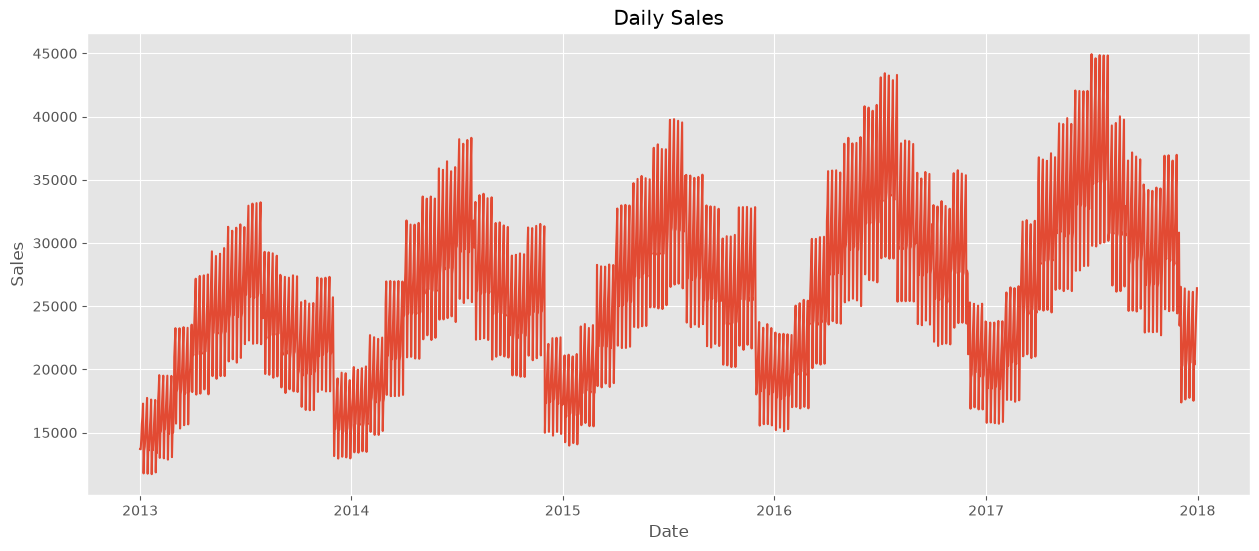

In [15]:
daily_sales = train.groupby("date")["sales"].sum().reset_index()

plt.figure(figsize=(15,6))
plt.plot(daily_sales["date"], daily_sales["sales"])
plt.title("Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

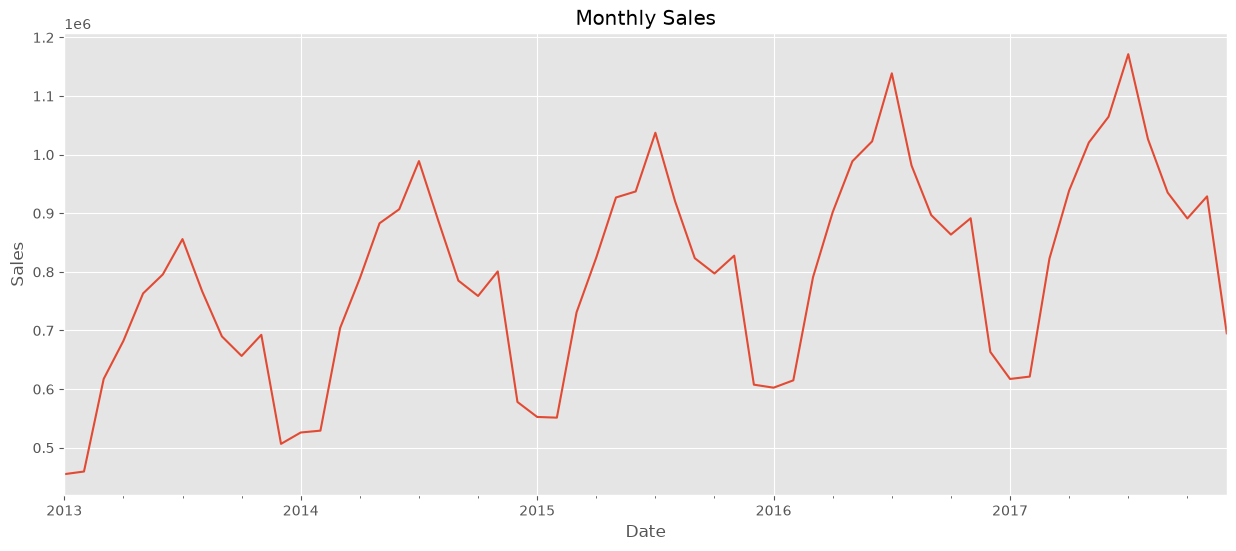

In [17]:
monthly_sales = train.resample("ME", on="date")["sales"].sum()
plt.figure(figsize=(15,6))
monthly_sales.plot()
plt.title("Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

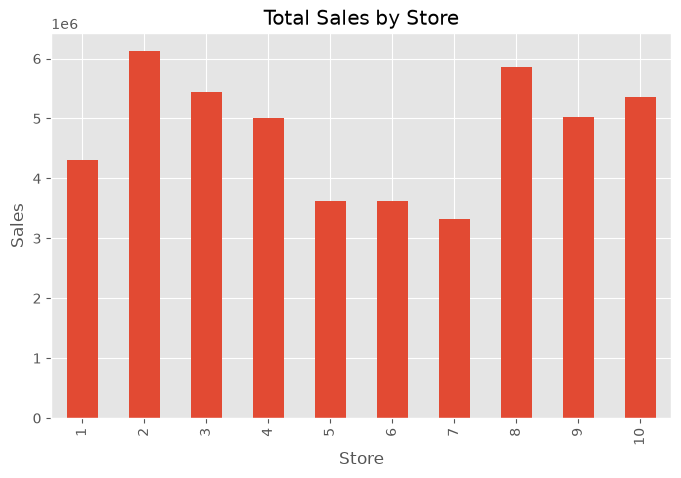

In [18]:
store_sales = train.groupby("store")["sales"].sum()

plt.figure(figsize=(8,5))
store_sales.plot(kind="bar")
plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Sales")
plt.show()

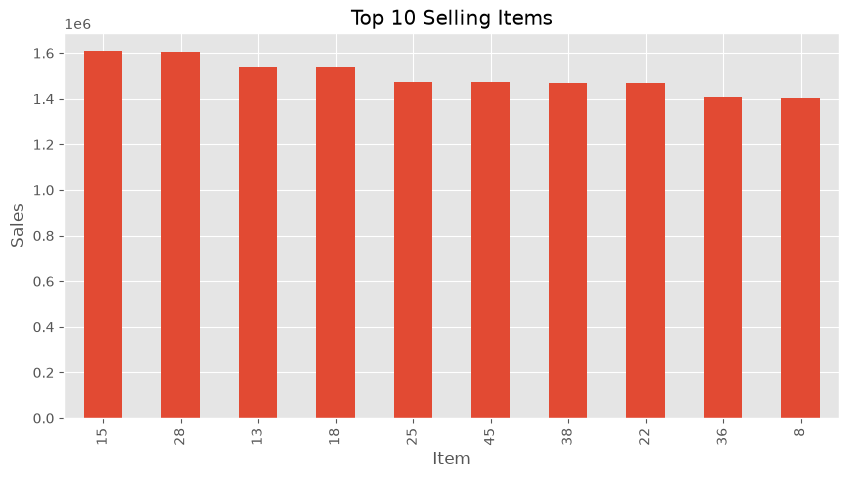

In [19]:
top_items = train.groupby("item")["sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_items.plot(kind="bar")
plt.title("Top 10 Selling Items")
plt.xlabel("Item")
plt.ylabel("Sales")
plt.show()

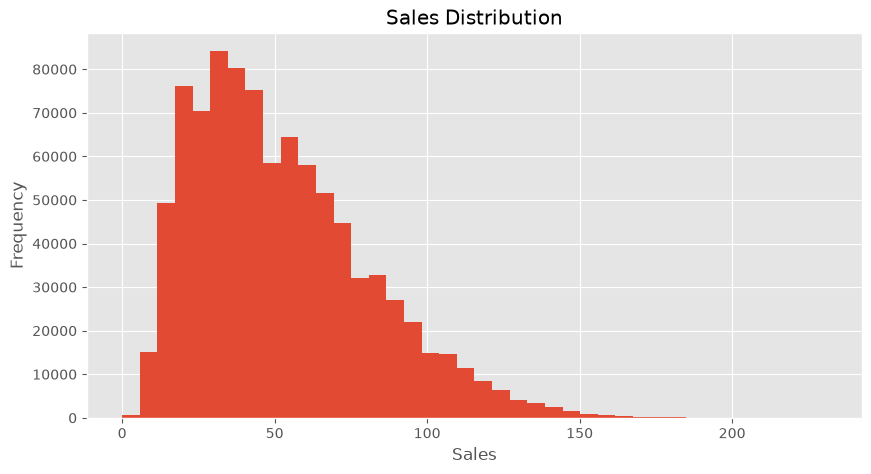

In [20]:
plt.figure(figsize=(10,5))
plt.hist(train["sales"], bins=40)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

C:\Users\rocky\AppData\Local\Temp\ipykernel_12468\1363149156.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(train["sales"], vert=False)


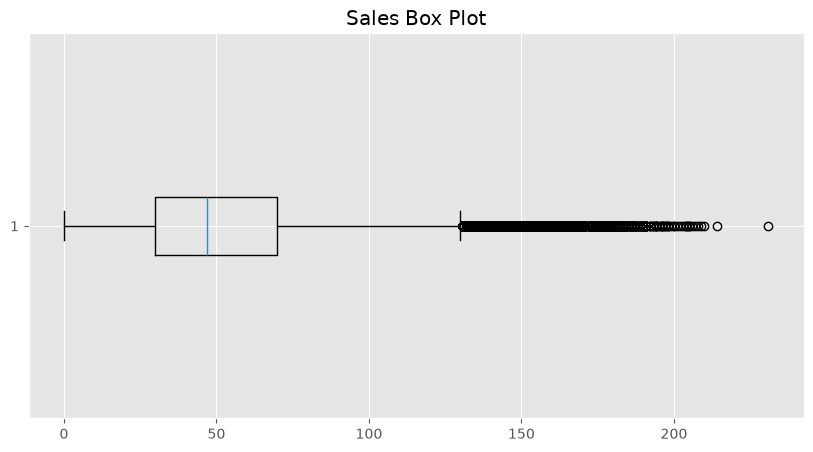

In [21]:
plt.figure(figsize=(10,5))
plt.boxplot(train["sales"], vert=False)
plt.title("Sales Box Plot")
plt.show()